# Deaths Involving Police in the United States

Since Jan 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has compiled a database of every fatal shooting in the US by a police officer in the line of duty. Here we explore that dataset alongside US census data (poverty rate, high-school graduation, median income and racial demographics) to look at the patterns in the data.

> **A note on reading this analysis.** This is a factual look at what the data records. A few things to keep in mind throughout:
> * This covers *fatal police shootings* only (roughly 2015 to mid-2017 in this snapshot) — not all deaths in custody, and not non-fatal incidents.
> * Most charts show **raw counts**. Raw counts track how many people live in a place, so 'more incidents' usually means 'more people', not 'more risk'. Per-capita *rates* would be needed to compare risk fairly.
> * **Correlation is not causation** — a relationship between two variables does not tell us that one causes the other.

## Import & Setup

In [1]:
%pip install --upgrade plotly -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

%matplotlib inline
# Render Plotly charts as images so they appear everywhere (incl. GitHub).
# Delete this line for interactive charts.
pio.renderers.default = "png"
sns.set_style("whitegrid")
pd.options.display.float_format = "{:,.2f}".format

## Load the Data

In [3]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

In [4]:
for name, d in [('income', df_hh_income), ('poverty', df_pct_poverty),
                ('hs', df_pct_completed_hs), ('race', df_share_race_city),
                ('fatalities', df_fatalities)]:
    print(f'{name:11} shape={d.shape}')

income      shape=(29322, 3)
poverty     shape=(29329, 3)
hs          shape=(29329, 3)
race        shape=(29268, 7)
fatalities  shape=(2535, 14)


In [5]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [6]:
# Missing values in the fatalities data
df_fatalities.isna().sum()

id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64

In [7]:
# Duplicates
print('duplicate fatality rows:', df_fatalities.duplicated().sum())

duplicate fatality rows: 0


## Data Cleaning

The census columns store missing/withheld values as text (`-`, `(X)`), and median income has ranges like `250,000+`. We coerce those to numbers. In the fatalities data we parse the `DD/MM/YY` dates and expand the single-letter race codes (W/B/H/A/N/O) to readable names.

In [8]:
# Census -> numeric
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')
df_hh_income['Median Income'] = pd.to_numeric(
    df_hh_income['Median Income'].astype(str)
        .str.replace(',', '', regex=False).str.replace('+', '', regex=False)
        .str.replace('-', '', regex=False), errors='coerce')

share_cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
for c in share_cols:
    df_share_race_city[c] = pd.to_numeric(df_share_race_city[c], errors='coerce')

# Fatalities: dates + readable race names
RACE = {'W': 'White', 'B': 'Black', 'H': 'Hispanic', 'A': 'Asian',
        'N': 'Native American', 'O': 'Other'}
df_fatalities['date'] = pd.to_datetime(df_fatalities['date'], format='%d/%m/%y', errors='coerce')
df_fatalities['race_name'] = df_fatalities['race'].map(RACE)
print('date range:', df_fatalities.date.min().date(), 'to', df_fatalities.date.max().date())

date range: 2015-01-02 to 2017-07-31


# Poverty Rate in each US State

Ranked from highest to lowest.

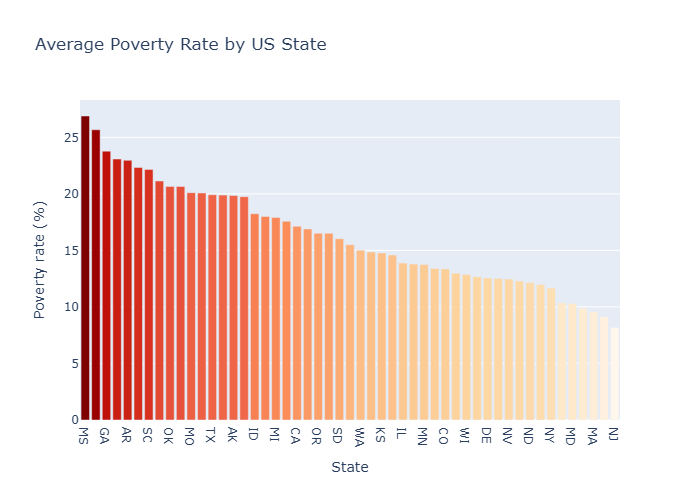

In [9]:
pov_state = (df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean()
             .sort_values(ascending=False))
fig = px.bar(x=pov_state.index, y=pov_state.values, color=pov_state.values,
             color_continuous_scale='OrRd',
             labels={'x': 'State', 'y': 'Poverty rate (%)'},
             title='Average Poverty Rate by US State')
fig.update_layout(coloraxis_showscale=False)
fig

> Mississippi has the highest average poverty rate (~27%) and New Jersey the lowest (~8%).

# High School Graduation Rate by US State

In ascending order.

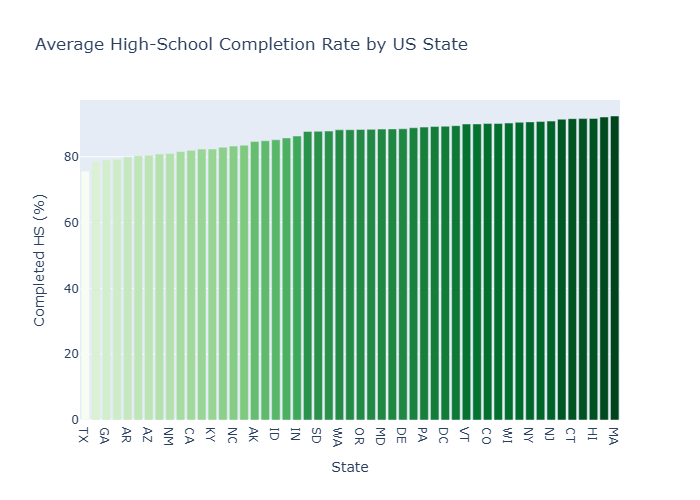

In [10]:
hs_state = (df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean()
            .sort_values())
fig = px.bar(x=hs_state.index, y=hs_state.values, color=hs_state.values,
             color_continuous_scale='Greens',
             labels={'x': 'State', 'y': 'Completed HS (%)'},
             title='Average High-School Completion Rate by US State')
fig.update_layout(coloraxis_showscale=False)
fig

# Relationship between Poverty and High School Graduation

### Dual-axis line chart

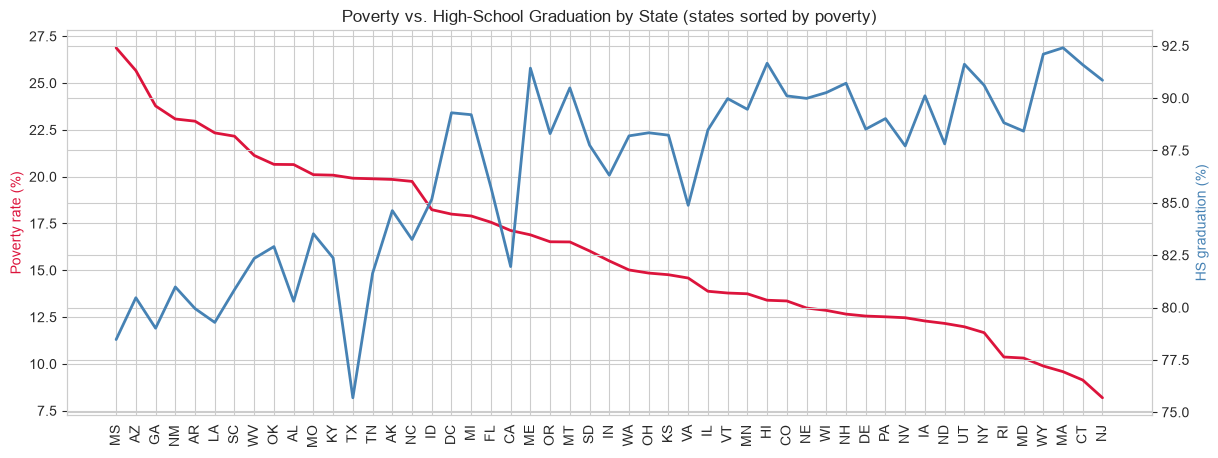

In [11]:
pov_s = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean()
hs_s = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean()
sdf = pd.concat([pov_s, hs_s], axis=1).dropna().sort_values('poverty_rate', ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.plot(sdf.index, sdf['poverty_rate'], color='crimson', lw=2, label='Poverty rate')
ax2.plot(sdf.index, sdf['percent_completed_hs'], color='steelblue', lw=2, label='HS graduation')
ax1.set_ylabel('Poverty rate (%)', color='crimson')
ax2.set_ylabel('HS graduation (%)', color='steelblue')
ax1.set_xticks(range(len(sdf))); ax1.set_xticklabels(sdf.index, rotation=90)
plt.title('Poverty vs. High-School Graduation by State (states sorted by poverty)')
plt.show()

> The two lines move in opposite directions: states with higher poverty tend to have lower graduation rates. This is a **correlation**, not evidence that one causes the other.

### Joint plot (KDE)

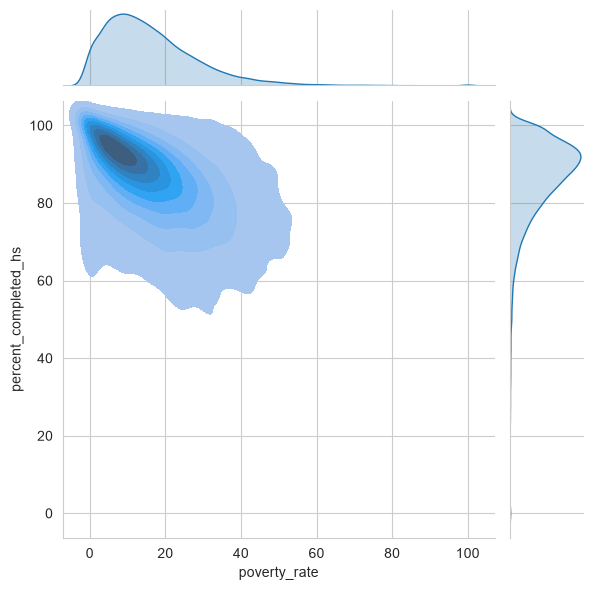

In [12]:
merged = pd.merge(df_pct_poverty, df_pct_completed_hs, on=['Geographic Area', 'City']).dropna(
    subset=['poverty_rate', 'percent_completed_hs'])
sns.jointplot(data=merged, x='poverty_rate', y='percent_completed_hs', kind='kde', fill=True, height=6)
plt.show()

### Linear regression

correlation: -0.5


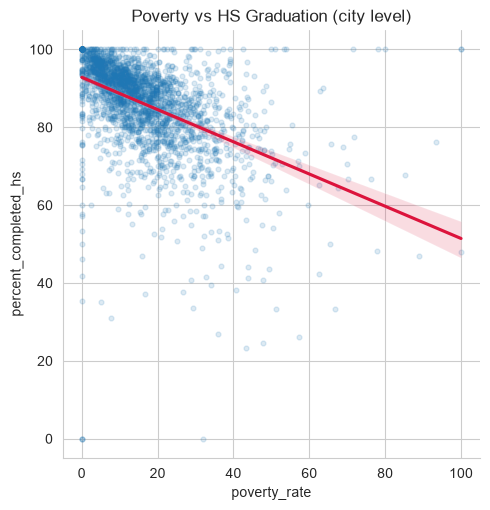

In [13]:
print('correlation:', round(merged['poverty_rate'].corr(merged['percent_completed_hs']), 3))
sns.lmplot(data=merged.sample(2500, random_state=1), x='poverty_rate', y='percent_completed_hs',
           height=5, line_kws={'color': 'crimson'}, scatter_kws={'alpha': 0.15, 's': 12})
plt.title('Poverty vs HS Graduation (city level)')
plt.show()

# Racial Makeup of Each US State

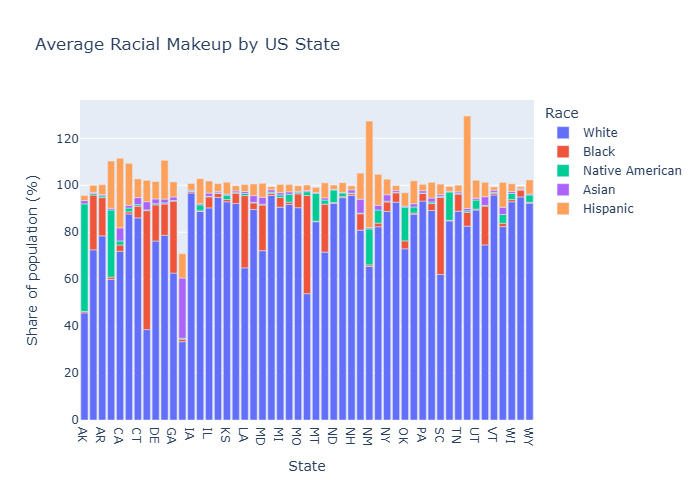

In [14]:
race_state = df_share_race_city.groupby('Geographic area')[share_cols].mean().reset_index()
melted = race_state.melt(id_vars='Geographic area', var_name='Race', value_name='Share')
melted['Race'] = melted['Race'].str.replace('share_', '').str.replace('_', ' ').str.title()
fig = px.bar(melted, x='Geographic area', y='Share', color='Race',
             title='Average Racial Makeup by US State',
             labels={'Geographic area': 'State', 'Share': 'Share of population (%)'})
fig

# People Killed, by Race (Donut)

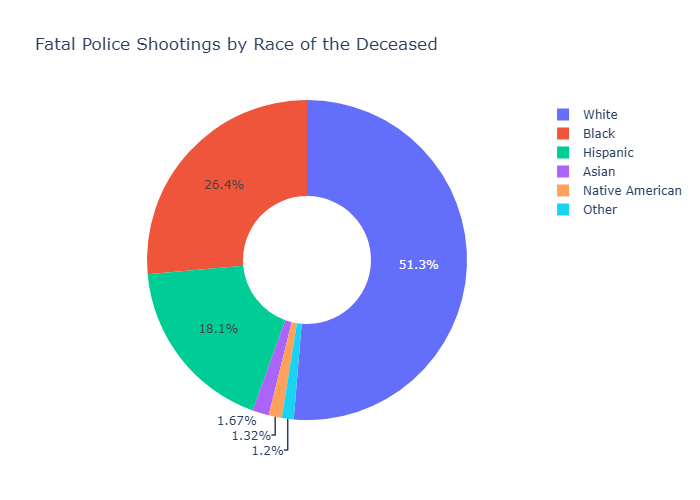

In [15]:
by_race = df_fatalities['race_name'].value_counts()
fig = px.pie(names=by_race.index, values=by_race.values, hole=0.4,
             title='Fatal Police Shootings by Race of the Deceased')
fig

> These are **raw counts**. To judge relative risk they should be read alongside each group's share of the population and per-capita rates — which this simple count does not show.

# Total Deaths: Men vs Women

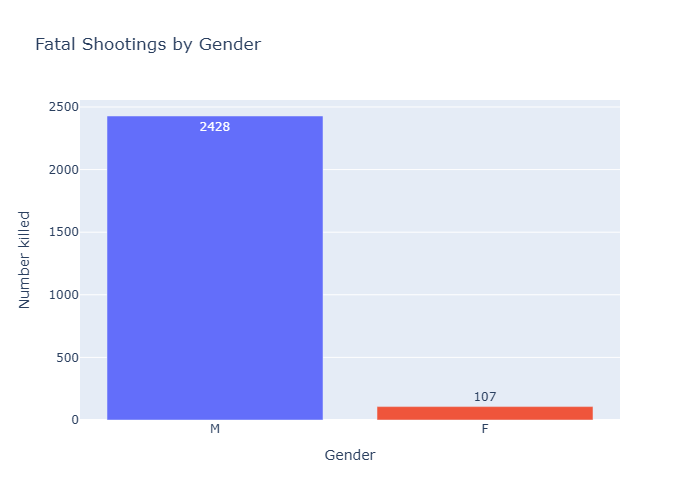

In [16]:
g = df_fatalities['gender'].value_counts()
fig = px.bar(x=g.index, y=g.values, color=g.index, text=g.values,
             labels={'x': 'Gender', 'y': 'Number killed'}, title='Fatal Shootings by Gender')
fig.update_layout(showlegend=False)
fig

> About **96%** of those killed were men.

# Age and Manner of Death (Box Plot, by Gender)

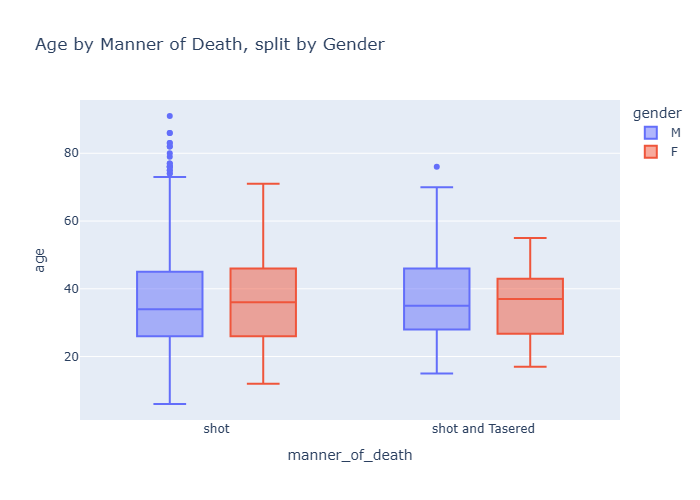

In [17]:
fig = px.box(df_fatalities.dropna(subset=['age']), x='manner_of_death', y='age', color='gender',
             title='Age by Manner of Death, split by Gender')
fig

# Were People Armed?

Armed with a gun: 1398
Recorded as unarmed: 171  (6.8% of cases with a record)


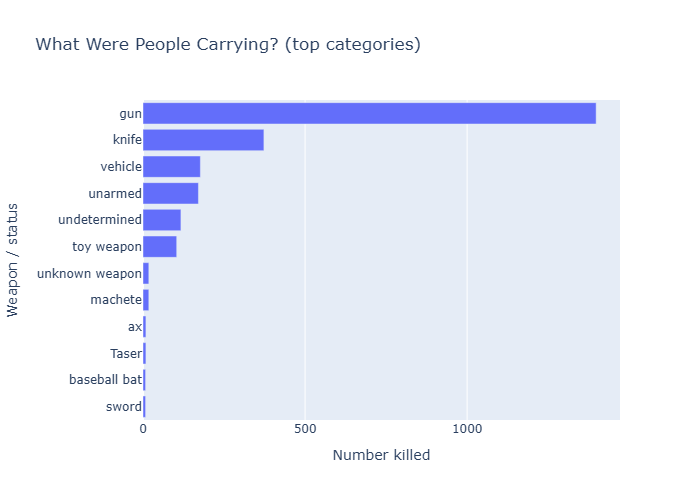

In [18]:
armed = df_fatalities['armed'].value_counts()
n_known = df_fatalities['armed'].notna().sum()
unarmed = int(armed.get('unarmed', 0))
print(f"Armed with a gun: {int(armed.get('gun', 0))}")
print(f"Recorded as unarmed: {unarmed}  ({unarmed / n_known * 100:.1f}% of cases with a record)")

top_armed = armed.head(12)
fig = px.bar(x=top_armed.values, y=top_armed.index, orientation='h',
             labels={'x': 'Number killed', 'y': 'Weapon / status'},
             title='What Were People Carrying? (top categories)')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig

# How Old Were the People Killed?

% under 25: 18.3%   |   median age: 34


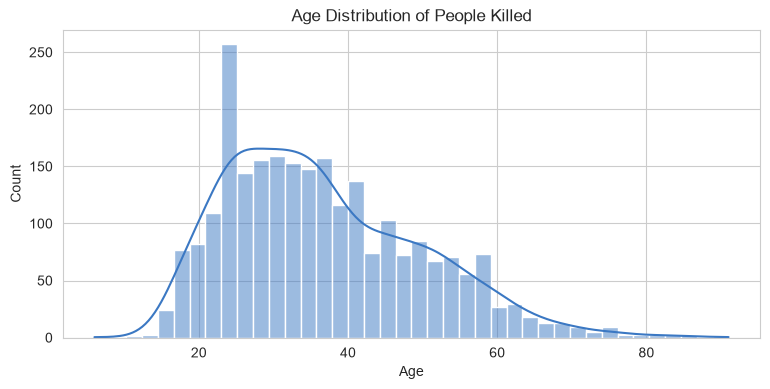

In [19]:
ages = df_fatalities['age'].dropna()
print(f"% under 25: {(ages < 25).mean() * 100:.1f}%   |   median age: {ages.median():.0f}")
plt.figure(figsize=(9, 4))
sns.histplot(ages, bins=40, kde=True, color='#3b78c3')
plt.title('Age Distribution of People Killed'); plt.xlabel('Age')
plt.show()

### Age Distribution by Race

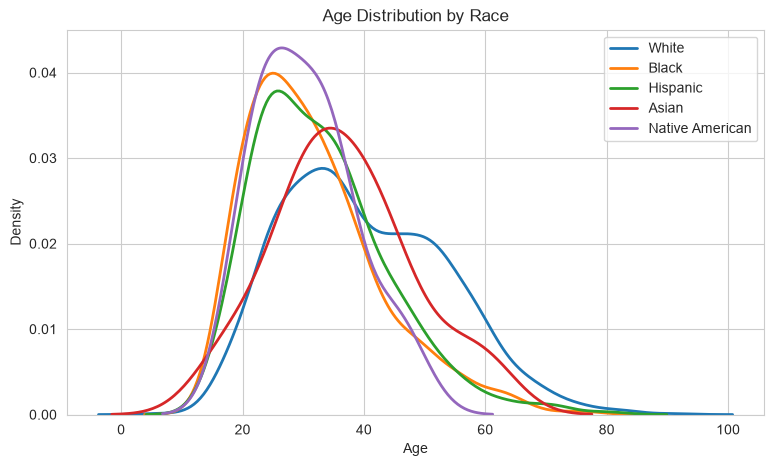

In [20]:
plt.figure(figsize=(9, 5))
for r in ['White', 'Black', 'Hispanic', 'Asian', 'Native American']:
    sns.kdeplot(df_fatalities.loc[df_fatalities.race_name == r, 'age'].dropna(), label=r, lw=2)
plt.legend(); plt.title('Age Distribution by Race'); plt.xlabel('Age')
plt.show()

# Race of People Killed (Totals)

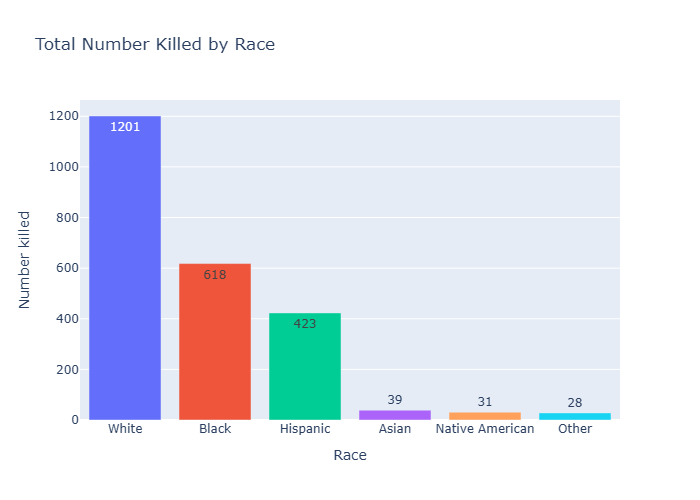

In [21]:
fig = px.bar(x=by_race.index, y=by_race.values, color=by_race.index, text=by_race.values,
             labels={'x': 'Race', 'y': 'Number killed'},
             title='Total Number Killed by Race')
fig.update_layout(showlegend=False)
fig

# Mental Illness and Police Killings

25.0% of people killed showed signs of mental illness.


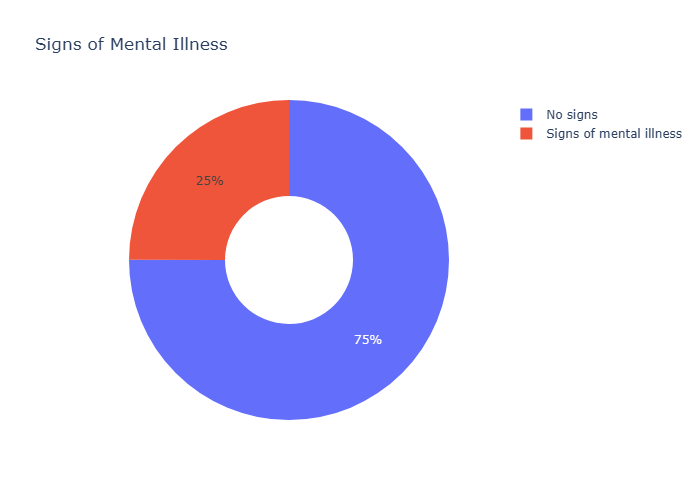

In [22]:
mi = df_fatalities['signs_of_mental_illness'].mean() * 100
print(f"{mi:.1f}% of people killed showed signs of mental illness.")
counts = df_fatalities['signs_of_mental_illness'].value_counts()
fig = px.pie(names=['Signs of mental illness' if k else 'No signs' for k in counts.index],
             values=counts.values, hole=0.4, title='Signs of Mental Illness')
fig

# Cities with the Most Police Killings

*(Highest **number** of incidents — note this largely tracks city population, not per-capita risk.)*

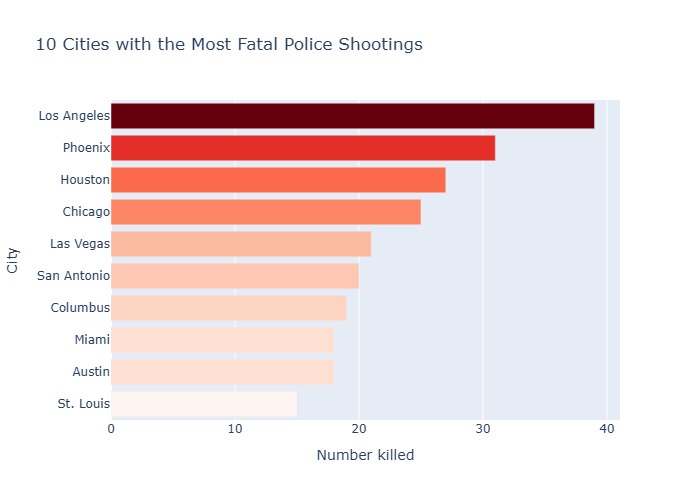

In [23]:
top_cities = df_fatalities['city'].value_counts().head(10)
fig = px.bar(x=top_cities.values, y=top_cities.index, orientation='h',
             color=top_cities.values, color_continuous_scale='Reds',
             labels={'x': 'Number killed', 'y': 'City'},
             title='10 Cities with the Most Fatal Police Shootings')
fig.update_layout(coloraxis_showscale=False, yaxis={'categoryorder': 'total ascending'})
fig

# Race of Victims in the Deadliest Cities

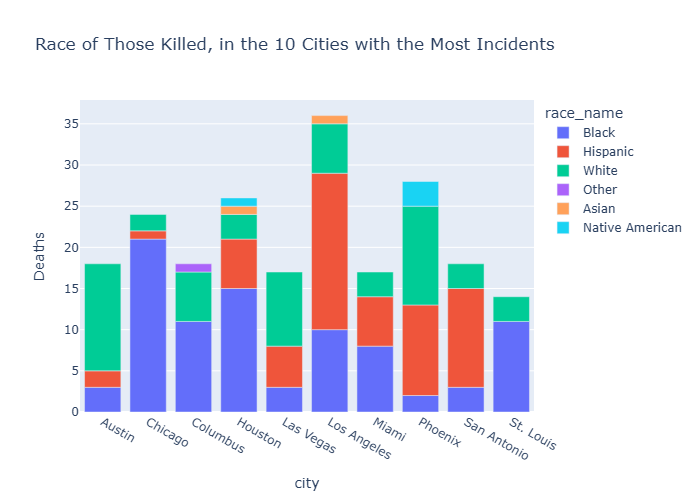

In [24]:
top10 = df_fatalities['city'].value_counts().head(10).index
city_race = (df_fatalities[df_fatalities.city.isin(top10)]
             .groupby(['city', 'race_name']).size().reset_index(name='Deaths'))
fig = px.bar(city_race, x='city', y='Deaths', color='race_name',
             title='Race of Those Killed, in the 10 Cities with the Most Incidents')
fig

> This shows the **composition** of victims in each city. A true per-race *rate* would also need each city's population by race, which isn't combined here.

# Police Killings by US State (Choropleth)

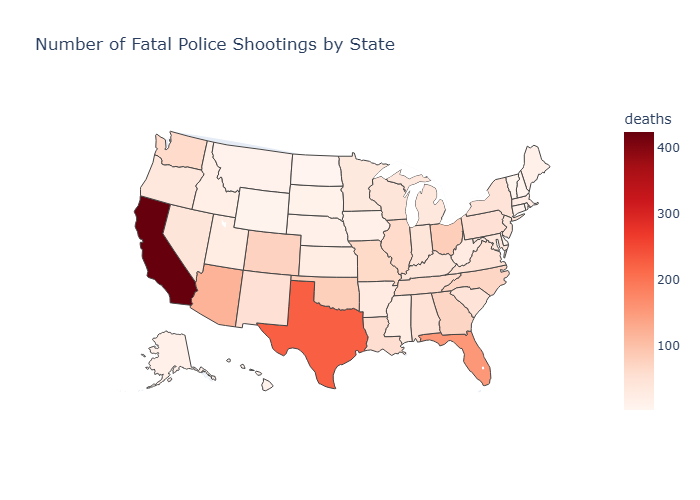

In [25]:
state_deaths = df_fatalities['state'].value_counts().reset_index()
state_deaths.columns = ['state', 'deaths']
fig = px.choropleth(state_deaths, locations='state', locationmode='USA-states',
                    color='deaths', scope='usa', color_continuous_scale='Reds',
                    title='Number of Fatal Police Shootings by State')
fig

> California, Texas and Florida have the highest counts — which are also the three most populous states, so this again reflects population more than risk.

# Number of Police Killings Over Time

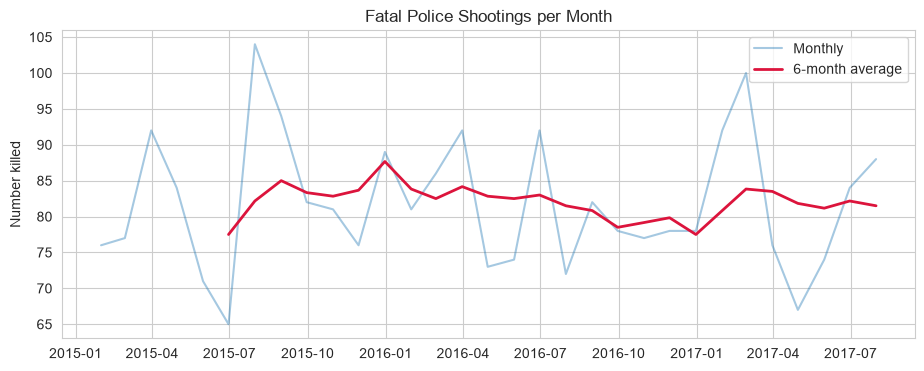

In [26]:
monthly = df_fatalities.dropna(subset=['date']).set_index('date').resample('ME').size()
rolling = monthly.rolling(6).mean()
plt.figure(figsize=(11, 4))
plt.plot(monthly.index, monthly.values, alpha=0.4, label='Monthly')
plt.plot(rolling.index, rolling.values, color='crimson', lw=2, label='6-month average')
plt.title('Fatal Police Shootings per Month'); plt.ylabel('Number killed'); plt.legend()
plt.show()

# Summary

Across this snapshot of the data (2015 to mid-2017):
* Around **96%** of those killed were men, and the **median age was 34**.
* In most cases the person was **armed** (most often with a gun); about **7%** were recorded as unarmed.
* **~25%** showed signs of mental illness.
* Incident **counts** are highest in the most populous states and cities (CA, TX, FL; Los Angeles) — a reminder that counts follow population, and per-capita **rates** are the right tool for comparing risk.
* At the state level, **higher poverty correlates with lower high-school graduation** — a relationship, not a cause.

For The Washington Post's own analysis, see their [police-shootings database](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).